In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

# Simulation source code
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
importlib.reload(sim)


Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [2]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

# Define directory where output files should be saved 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/" 
# Make a directory for the output files inside the output directory with today's date, inside of that make a directory for the run with the current time
date=datetime.datetime.now().strftime("%Y-%m-%d")
time=datetime.datetime.now().strftime("%H-%M-%S")
output_dir = os.path.join(output_dir, date, time)

os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-18/11-17-40


In [3]:
# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

### Simulate data!

In [4]:
# Filter adata to only include junctions that have non_zero_count_cells >= 10
adata = adata[:, adata.var["non_zero_count_cells"] >= 5]

In [5]:
# choose which column should be used for maintaining cell labels when simulating data...
sim_label_column = None #"cell_type_grouped" # or set to None then cells will be randomly assigned to groups
proportion_negative = 0.5
K = 2 # number of groups to simulate, if sim_label_column is None then this K value will be used otherwise it will be inferred from the column

In [6]:
# Preprocess the data
adata_filtered = sim.preprocess_adata(adata, sim_label_column, "cell_by_cluster_matrix")

No cell type column specified. Skipping filtering of ATSEs.


In [7]:
# Simulate data
_, _, adata_input, cell_type_psi_df = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, sim_label_column)

/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:281: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_junc_counts =  adata_input.var.groupby(["event_id"]).agg({"junction_id": "count"}).reset_index()
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:307: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, juncs_c in tqdm( adata_input.var.groupby("event_id")):


Cluster_Counts nnz: 14850384
Junction_Counts nnz: 8481661
The number of unique junctions included in the simulation data is: 9708
The number of unique clusters included in the simulation data is: 3236


100%|██████████| 3236/3236 [00:02<00:00, 1229.64it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 13634574
Junction_Counts nnz: 7432281
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 2
The number of cells is: 19942
The number of junctions is: 8916
Number of negative labels (0): 1486
Number of positive labels (1): 1486


100%|██████████| 2972/2972 [00:07<00:00, 415.68it/s]


...

Processing ATSEs: 100%|██████████| 2972/2972 [00:51<00:00, 57.38it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Done normalizing junction counts by cluster!
Done simulating junction counts!
True label counts:
 true_label
negative    4458
positive    4458
Name: count, dtype: int64
Sample label counts:
 sample_label
negative    4458
positive    4458
Name: count, dtype: int64


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'junc_ratio' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Cluster_Counts nnz: 13475409
Junction_Counts nnz: 11671498
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [8]:
adata_input.layers["junc_ratio"]

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ..., 0.55555556, 0.        ,
        0.44444444],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

In [9]:
# Write cell_type_psi_df to a CSV file 
# ----------------------------------------------------------
# cell_type_psi_df_path = os.path.join(output_dir, 'cell_type_psi_df.csv')
# cell_type_psi_df.to_csv(cell_type_psi_df_path, index=False)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


     junction_id_index               junction_id  difference true_label
0                 5364  chr3_96046462_96046997_-         0.0   negative
809               5365  chr3_96046462_96047246_-         0.0   negative
1618              5366  chr3_96047135_96047246_-         0.0   negative
cell_type
0    1257
1    1170
Name: count, dtype: int64
Number of non-zero cells: 809


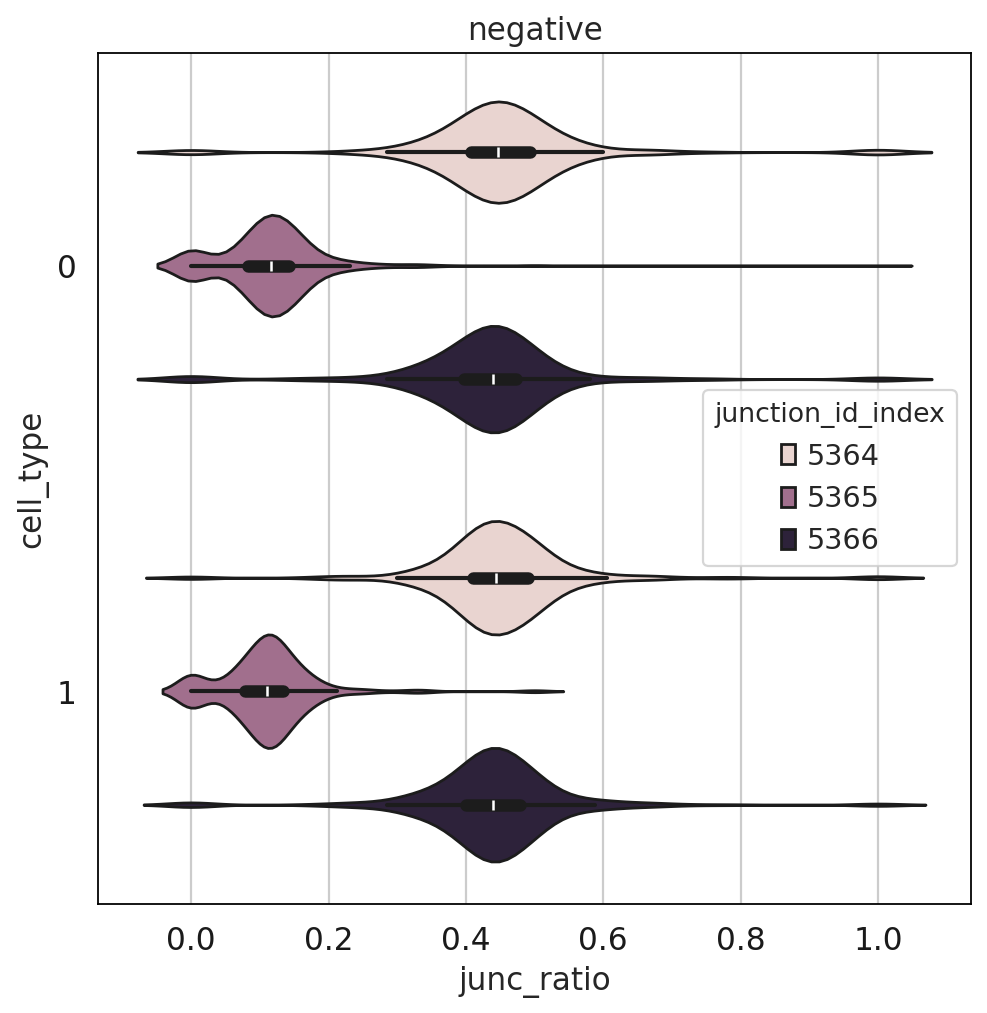

In [27]:
# randomly sample a unique event_id from adata_input.var["event_id"].unique()
event = np.random.choice(adata_input.var["event_id"].unique())
df = sim.quick_clust_plot(event, adata_input)

### Initialize and train the model using the simulated counts!

In [29]:
# Set up some useful params 
input_conc = torch.tensor(np.inf) #torch.tensor(np.inf) # can also set as torch.tensor(np.inf) for binomial likelihood or None (beta-binomial likelihood will be used)
junc_specific_prior = False # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
waypoints_use = False # don't have waypoints in simulated data
num_inits = 10
num_epochs = 50
print_epochs = 5
num_samples = 500
lr = 0.8

Taking in the AnnData object with 19942 cells and 8916 junctions.
Processing AnnData on cuda
Random seeds: [7377, 7503, 7319, 2003, 7813, 6061, 8792, 2550, 6943, 1598]
Training LeafletFA with 10 initializations.
Input concentration prior: inf
Junction-specific prior: False
Initial K to learn: 2
Random initialization of variational parameters!
-------------------------------------------------
Initialization #1 with seed 7377
-------------------------------------------------
Training in progress for 50 epochs!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Epoch 0: Loss = 474136151.63598317
Epoch 5: Loss = 149151701.87617874
Epoch 10: Loss = 105852639.72765096
Epoch 15: Loss = 58957139.49596968
Epoch 20: Loss = 40025544.95920889
Epoch 25: Loss = 32941542.549235895
Epoch 30: Loss = 30138764.32874891
Epoch 35: Loss = 28900996.368744116
Epoch 40: Loss = 28330487.01810421
Epoch 45: Loss = 27973539.685647994
Training completed after 50 epochs with loss: 27813900.916878775
No output directory specified, skipping loss plot save.
Computing summary statistics for initialization #1
-------------------------------------------------
Initialization #2 with seed 7503
-------------------------------------------------
Training in progress for 50 epochs!
Epoch 0: Loss = 370413061.40458065
Epoch 5: Loss = 111582471.3162574
Epoch 10: Loss = 46831632.172530845
Epoch 15: Loss = 35157285.007419065
Epoch 20: Loss = 30060989.304613527
Epoch 25: Loss = 28687172.032896828
Epoch 30: Loss = 27894096.821274515
Epoch 35: Loss = 27572827.248242952
Epoch 40: Loss = 274

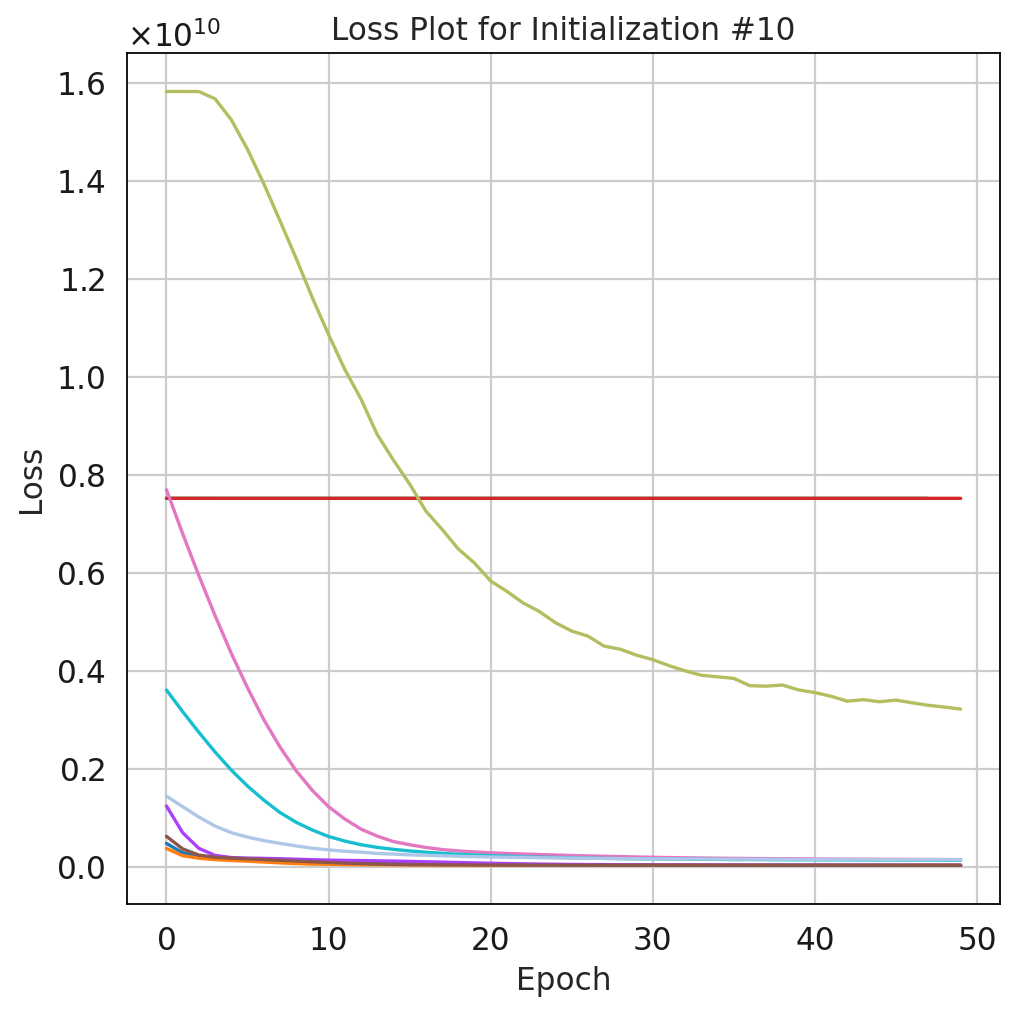

In [30]:
# Let's initialize the LeafletFA class 
leaflet_model = LeafletFA.LeafletFA(adata=adata_input, K=K, junc_specific_prior = junc_specific_prior, 
                                    waypoints_use=waypoints_use, 
                           input_conc_prior = input_conc, 
                           num_epochs=num_epochs, print_epochs=print_epochs, 
                           ELBO_num_particles=10, 
                           lr=lr, gamma=0.05, 
                           num_samples=num_samples)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

# Train the model 
leaflet_model.train(num_initializations=num_inits)

# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

Initialization 1 vs Initialization 2: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 4: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 5: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 6: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 7: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 8: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 9: Matched pairs [(0, 0), (1, 1)]
Initialization 1 vs Initialization 10: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 0), (1, 1)]
Initialization 2 vs Initialization 4: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 5: Matched pairs [(0, 1), (1, 0)]
Initialization 2 vs Initialization 6: Matched pairs [(0, 0), (1, 1)]
Initialization 2 vs Initialization 7: Matched pairs [(0, 0), (1, 1)]
Initialization 2 vs Initializatio

<Figure size 560x560 with 0 Axes>

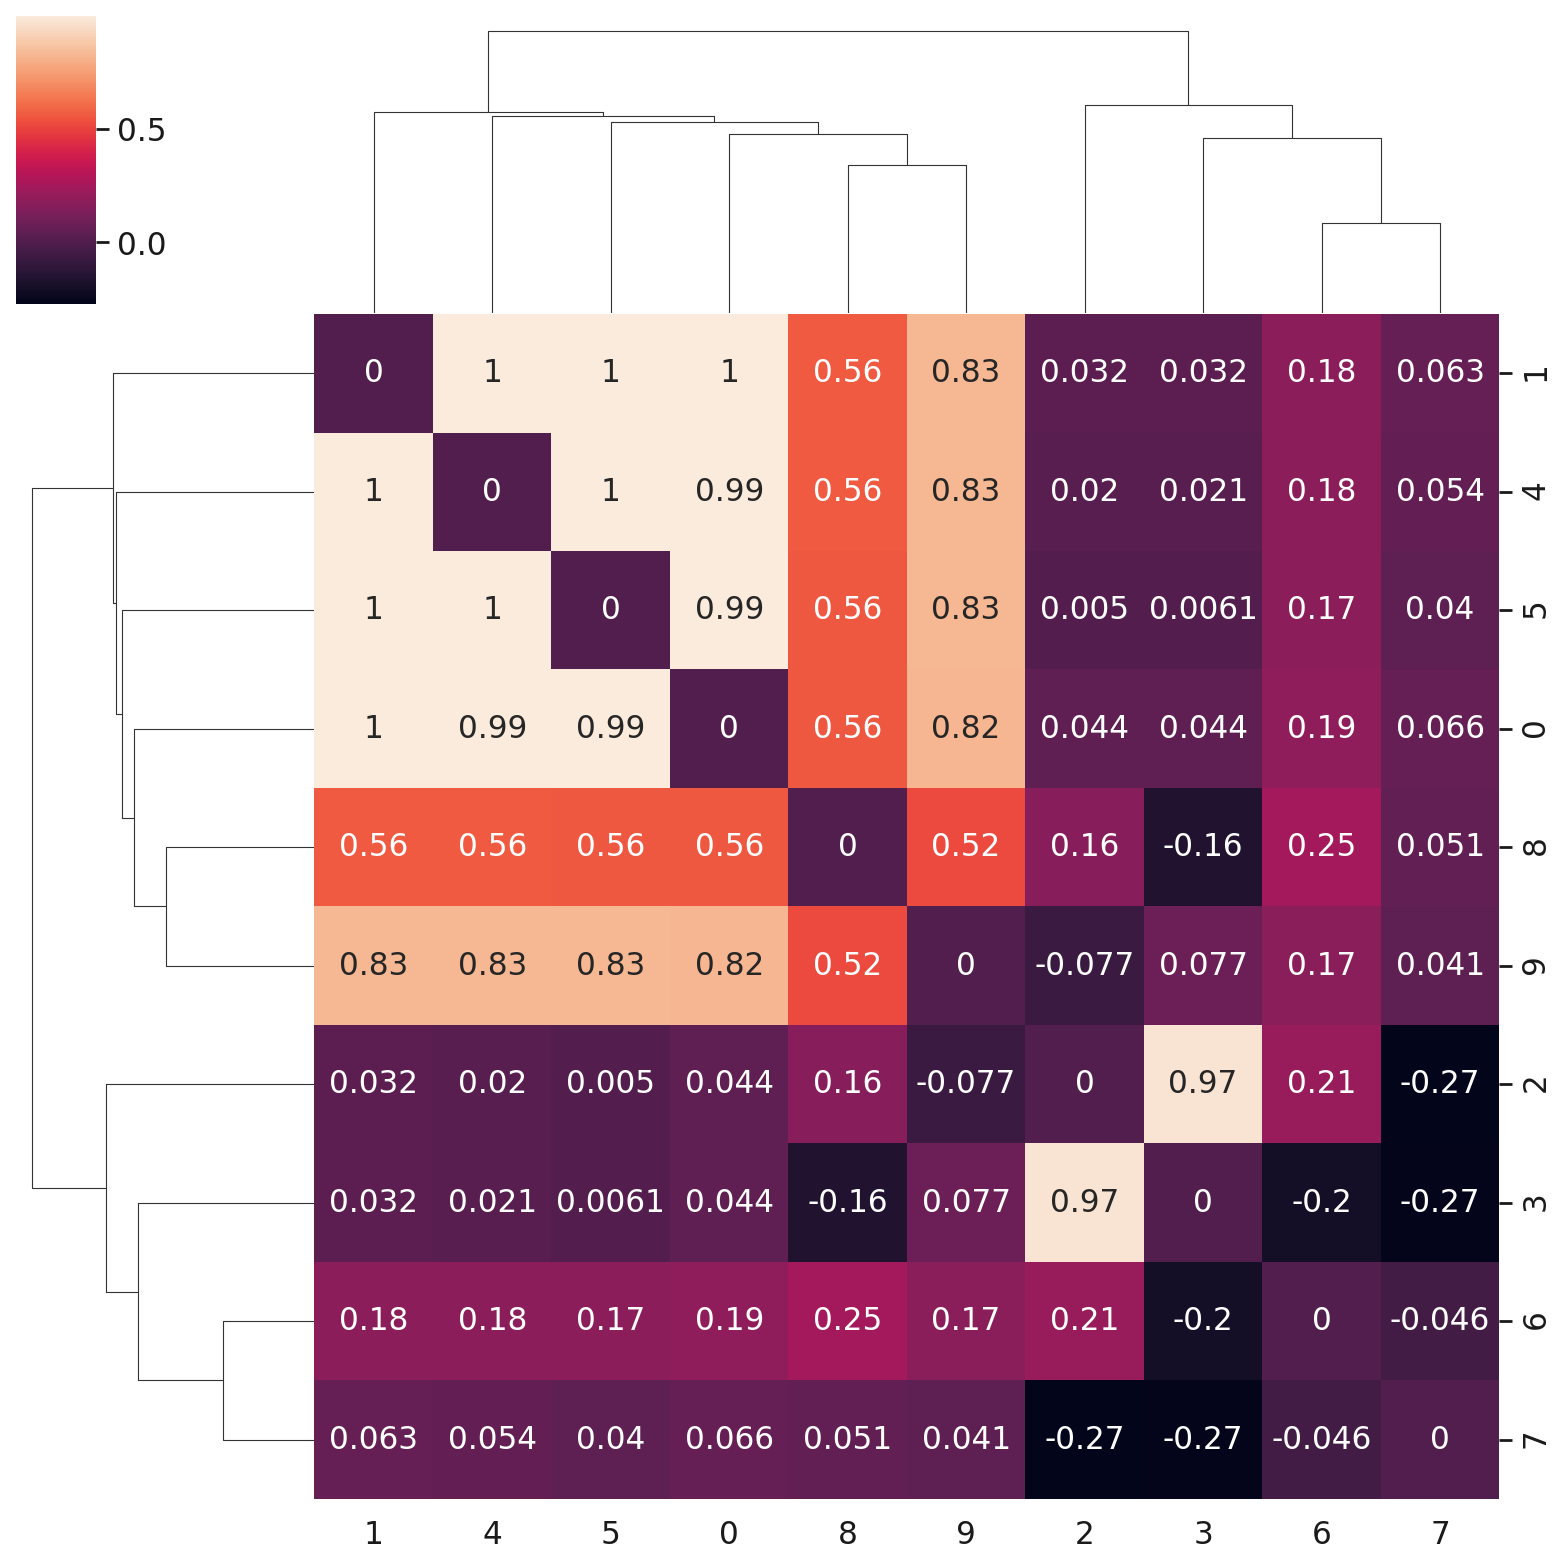

In [31]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [32]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 2
The K after pruning is 2
Upating K to 2 in the LeafletFA object.


In [33]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata_input.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 
sc.pp.neighbors(adata_input, use_rep=LEAFLETFA_LATENT_KEY, n_neighbors=10)

... storing 'event_id' as categorical
... storing 'chr' as categorical
... storing 'start' as categorical
... storing 'end' as categorical
... storing 'sample_label' as categorical
... storing 'true_label' as categorical


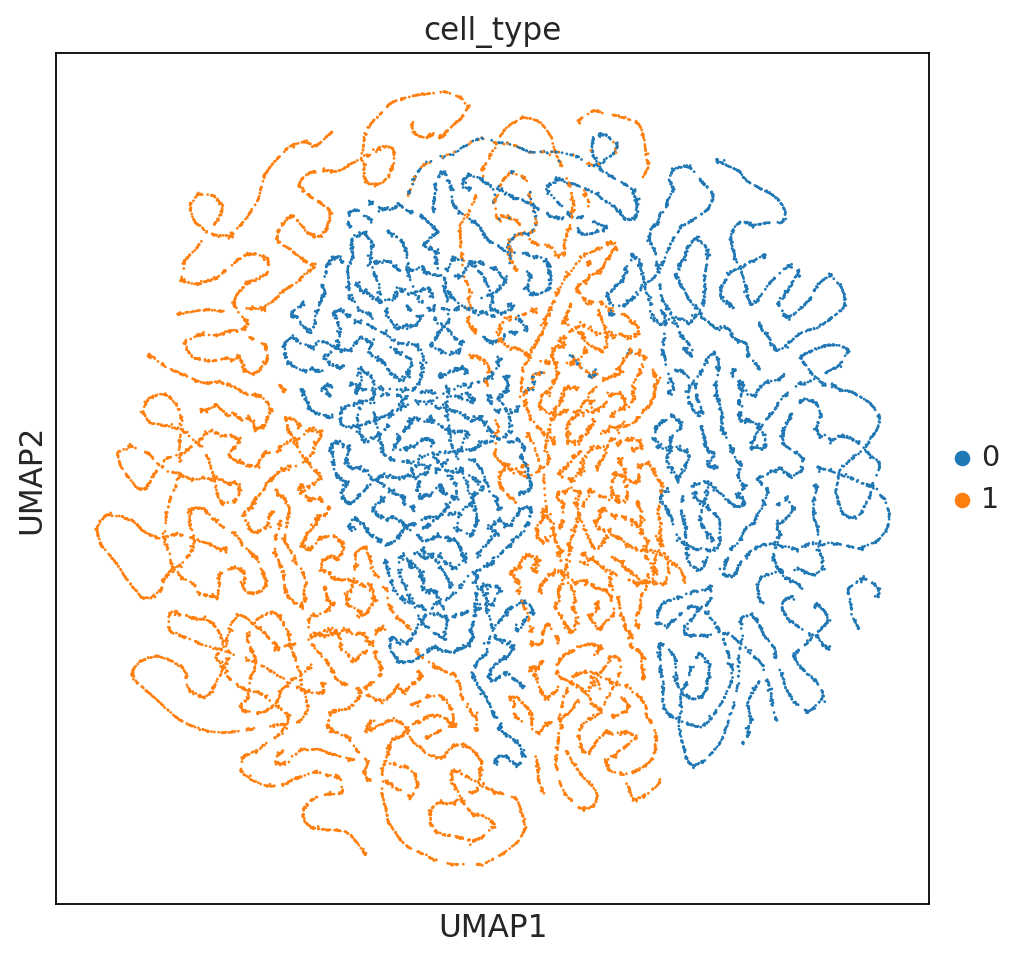

In [34]:
sc.tl.umap(adata_input)
sc.pl.umap(adata_input, color=["cell_type"])

In [35]:
cell_tye_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata_input.obs.cell_type.values)
print(f"Silhouette score for cell types: {cell_tye_silhouette}")

Silhouette score for cell types: 0.9601022601127625


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


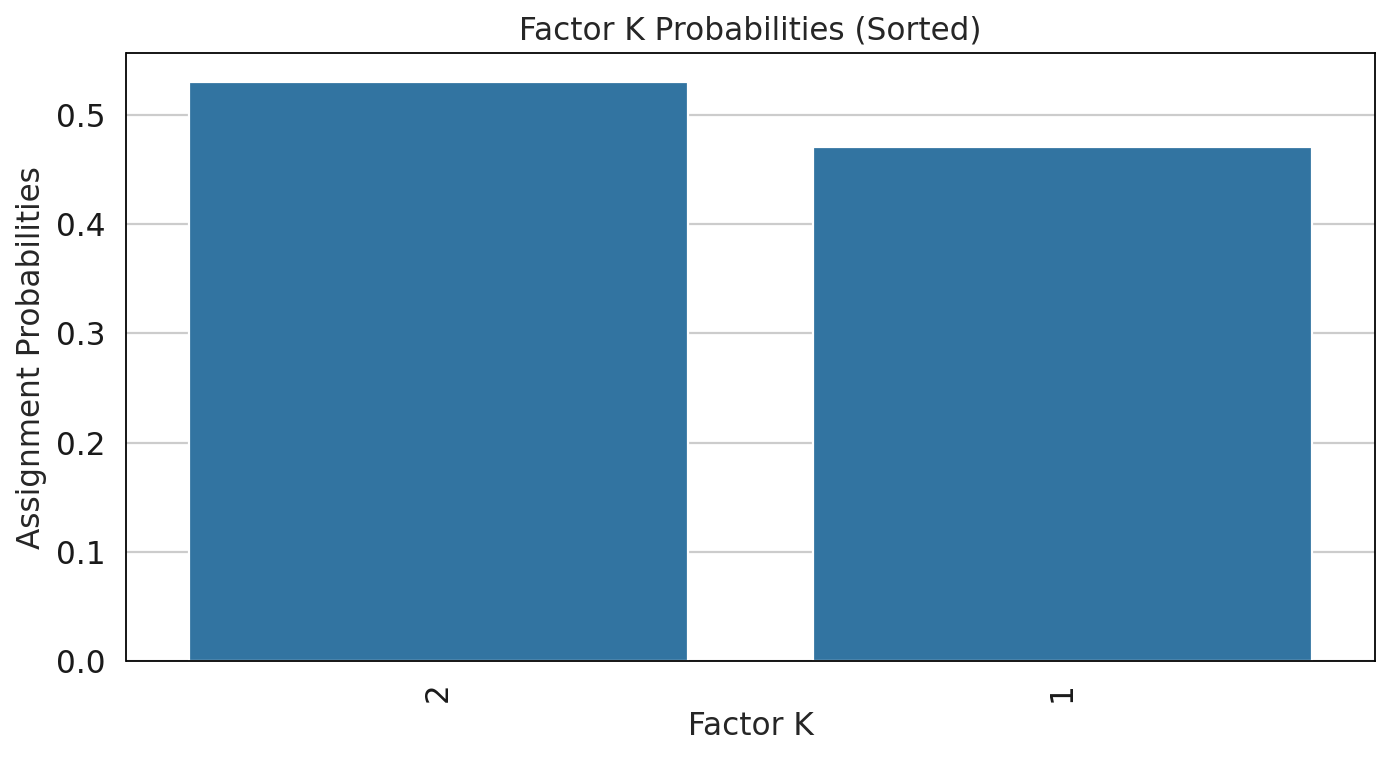

In [36]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index+1

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(10, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

In [49]:
# Let's extract sampled PSI means to calculate imputed difference between groups
# convert leaflet_model.psi_samples to a dataframe rename columns to factor_
factor_psi_df = pd.DataFrame(leaflet_model.psi_learned.T)
factor_psi_df.columns = [f"factor_imputed_psi_{col}" for col in factor_psi_df.columns]
factor_psi_df["imputed_diff"] = np.abs(factor_psi_df["factor_imputed_psi_0"] - factor_psi_df["factor_imputed_psi_1"])

In [50]:
# Add factor_psi_df to adata_input.var 
adata_input.var = pd.concat([adata_input.var, factor_psi_df], axis=1)

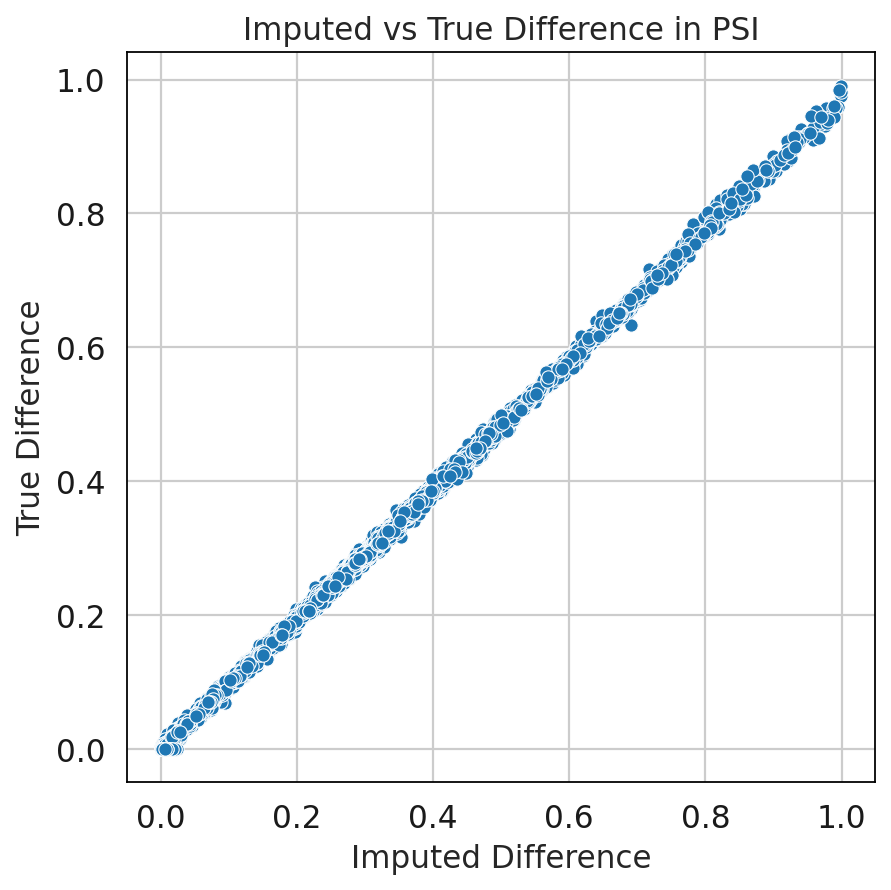

Pearson correlation between imputed and true difference: 0.9998000368874004
Spearman correlation between imputed and true difference: 0.933615564325223


In [54]:
# Plot scatterplot correlation between imputed difference and true difference 
plt.figure(figsize=(6, 6))
sns.scatterplot(x="imputed_diff", y="difference", data=adata_input.var)
plt.xlabel("Imputed Difference")
plt.ylabel("True Difference")
plt.title("Imputed vs True Difference in PSI")
plt.show()

# Calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
spearman_corr = stats.spearmanr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
print(f"Pearson correlation between imputed and true difference: {pearson_corr}")
print(f"Spearman correlation between imputed and true difference: {spearman_corr}")

In [ ]:
# Let's approximate population specific junction usage ratios 
# For every cell in factor 1 (or any factor), get phi_ck times psi_kj for all junctions j 
# For all other factors, get sum of phi_ck times psi_kj for all junctions j across remaining factors
# Then calculate the difference between the two groups (that's our effect size...)
# Null hypothesis is that the difference is 0 or null hpothesis |beta_j| <= delta (change mode in scvi)
# Select delta via false discovery rate (FDR) control for example 
# mu_j^t is 1 if j tagged as differential, 0 otherwise 
# where decision rule is to tag top t junctions of highest |beta_j| as differential splicing 
# d^j is binary random variable taking on value 1 if j is tagged as differential and 0 otherwise
# FDP random variable corresponding to the ratio of false positives over total # of predicted positives 
# FDR for mu^t is sum over j (1-d^j)*mu_j^t / sum over j (muj^t)

psi = 

In [ ]:
adata_plot = adata_input.copy()
adata_input.var.index = adata_input.var["junction_id_index"]
adata_input.var_names = adata_input.var.index

In [ ]:
leaflet_model.psi_samples_mean, leaflet_model.psi_samples_std

In [ ]:
LEAFLETFA_SJ_DSS_KEY = "SJ_DSS_SAMPLED"
SJ_DSS = ds.compute_z_score_dss(leaflet_model.psi_samples_mean, leaflet_model.psi_samples_std, leaflet_model.pi, adata_input.var_names)
SJ_DSS.index = adata_input.var_names
adata_input.varm[LEAFLETFA_SJ_DSS_KEY] = SJ_DSS
# Combine SJ_DSS with adata.var 
# Add perplexity values to AnnData var object 
perplexity_df = ds.compute_junction_perplexity(adata_input, leafletfa_sj_dss_key="SJ_DSS_SAMPLED")
adata_input.var["perplexity"] = perplexity_df["Perplexity"].values

In [ ]:
adata_input.var = pd.concat([adata_input.var, SJ_DSS], axis=1)

In [ ]:
# look at distribution of z-scores in factor_0 and factor_1
plt.figure(figsize=(8, 5))
sns.histplot(SJ_DSS["factor_0"], bins=100, color="blue", alpha=0.5, label="Factor 0")
sns.histplot(SJ_DSS["factor_1"], bins=100, color="red", alpha=0.5, label="Factor 1")
plt.xlabel("Z-Score")
plt.ylabel("Frequency")

In [ ]:
# look at distribution of z-scores in factor_0 and factor_1
plt.figure(figsize=(8, 5))
sns.histplot(SJ_DSS["factor_0_pvalue"], bins=100, color="blue", alpha=0.5, label="Factor 0")
sns.histplot(SJ_DSS["factor_1_pvalue"], bins=100, color="red", alpha=0.5, label="Factor 1")
plt.xlabel("p-value")
plt.ylabel("Frequency")

In [ ]:
SJ_DSS.sort_values(by="factor_1", ascending=False).head(5)

In [ ]:
# For a given junction, let's extract it's sampled PSI values and plot them for each factor 
junction_id = 4597	
sampled_psis = leaflet_model.psi_samples[:, :, junction_id] # shape is (num_samples, K)
plt.figure(figsize=(6, 6))
sns.violinplot(data=sampled_psis, inner="quart", scale="width", linewidth=1.5)
plt.xlabel("Factor K")
plt.ylabel("Sampled PSI")

In [ ]:
leaflet_model.psi_samples[:, :, junction_id].mean(dim=0)

In [ ]:
cell_type_psi_df[cell_type_psi_df["junction_id_index"] == junction_id]

In [ ]:
event=adata_plot.var[adata_plot.var["junction_id_index"] == junction_id].event_id[0]

In [ ]:
# randomly sample a unique event_id from adata_input.var["event_id"].unique()
junc_df = sim.quick_clust_plot(event, adata_plot)

In [ ]:
neg_juncs = adata_input.var[adata_input.var["true_label"] == "negative"]
neg_juncs

In [ ]:
# let's add the predicted difference 

In [ ]:
pos_juncs = adata_input.var[adata_input.var["true_label"] == "positive"]
pos_juncs

In [ ]:
sns.histplot(adata_input.var["factor_0"][adata_input.var["true_label"] == "positive"], bins=100, color="blue", alpha=0.5, label="Negative")